# Notebook 3: AI Modelling
## EEEM073 – AI and Sustainability
### Project: Predicting Burned Area of Forest Fires Using Machine Learning

**Prerequisite:** Run Notebooks 1 and 2 first.

---
This notebook implements and trains **three supervised ML models**:

| # | Model | Type | Justification |
|---|---|---|---|
| 1 | **Random Forest** | Tree ensemble | Strong baseline; handles non-linearity; interpretable |
| 2 | **MLP (Neural Network)** | Deep learning | Flexible function approximator; good comparison to Transformer |
| 3 | **Tabular Transformer** | Attention-based DL | State-of-the-art; module week 4; Nascimento et al. (2023) |

Steps:
1. Load preprocessed data
2. Model 1 — Random Forest with hyperparameter tuning
3. Model 2 — MLP (Multi-Layer Perceptron)
4. Model 3 — Tabular Transformer
5. Training curves comparison
6. Save all models and results


## 1. Imports and Data Loading

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import warnings
import json
import joblib

# Scikit-learn — Random Forest and metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch — MLP and Transformer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.6.0+cu124


In [2]:
# Load preprocessed data from Notebook 1 outputs
X_train = pd.read_csv('outputs/X_train.csv')
X_val   = pd.read_csv('outputs/X_val.csv')
X_test  = pd.read_csv('outputs/X_test.csv')
y_train = pd.read_csv('outputs/y_train.csv').squeeze()
y_val   = pd.read_csv('outputs/y_val.csv').squeeze()
y_test  = pd.read_csv('outputs/y_test.csv').squeeze()

feature_names = pd.read_csv('outputs/feature_names.csv')['feature'].tolist()
n_features = X_train.shape[1]

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Number of features: {n_features}")
print(f"Features: {feature_names}")

Training samples:   361
Validation samples: 78
Test samples:       78
Number of features: 18
Features: ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'temp_RH_ratio', 'fire_spread_potential', 'FWI_total', 'drought_wind']


In [4]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    """
    Compute and print regression evaluation metrics.
    
    Metrics used:
      - MAE  (Mean Absolute Error): average prediction error in log1p units
      - RMSE (Root Mean Squared Error): penalises large errors more than MAE
      - R²   (Coefficient of Determination): proportion of variance explained (1.0 = perfect)
    
    Args:
        y_true (array): Ground truth values
        y_pred (array): Model predictions
        model_name (str): Label for display
    Returns:
        dict: Dictionary of metric values
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {model_name:<30} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Dictionary to store all results for comparison in Notebook 4
all_results = {}

---
## 2. Model 1 — Random Forest Regressor

### Why Random Forest?
Random Forest is an ensemble of decision trees. Each tree is trained on a random subset of data and features, and the final prediction is the average across all trees. It handles non-linear relationships well, is robust to overfitting, and provides feature importance natively — useful for our XAI analysis in Notebook 4.

**Strengths:** Robust, interpretable, handles non-linearity, no scaling needed  
**Weaknesses:** Large memory footprint, slower inference than simple models

In [5]:
print("=" * 55)
print("MODEL 1: Random Forest Regressor")
print("=" * 55)

# Hyperparameter grid to search over
# n_estimators: number of trees — more trees = better but slower
# max_depth: how deep each tree grows — limits overfitting
# min_samples_split: minimum samples needed to split a node
param_grid_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':     ['sqrt', 'log2']
}

# GridSearchCV performs cross-validation across all parameter combinations
# cv=5 means 5-fold cross-validation on the training set
# scoring='neg_mean_squared_error' — minimise MSE
rf_base = RandomForestRegressor(random_state=SEED, n_jobs=-1)

print("Running GridSearchCV (this may take ~1-2 minutes)...")
start = time.time()

rf_search = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train, y_train)

rf_time = time.time() - start
print(f"GridSearch complete in {rf_time:.1f}s")
print(f"Best parameters: {rf_search.best_params_}")

# Use the best model found
rf_model = rf_search.best_estimator_

MODEL 1: Random Forest Regressor
Running GridSearchCV (this may take ~1-2 minutes)...
GridSearch complete in 27.3s
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}


In [6]:
# Evaluate Random Forest on validation and test sets
rf_train_pred = rf_model.predict(X_train)
rf_val_pred   = rf_model.predict(X_val)
rf_test_pred  = rf_model.predict(X_test)

print("Random Forest Performance:")
rf_train_metrics = evaluate_model(y_train, rf_train_pred, 'RF — Train')
rf_val_metrics   = evaluate_model(y_val,   rf_val_pred,   'RF — Validation')
rf_test_metrics  = evaluate_model(y_test,  rf_test_pred,  'RF — Test')

# Check for overfitting: if train R² >> val R², the model is overfitting
gap = rf_train_metrics['R2'] - rf_val_metrics['R2']
print(f"\nTrain vs Val R² gap: {gap:.4f} (< 0.10 is acceptable, < 0.05 is good)")

# Record model size (robust for different sklearn versions)
try:
    rf_size_mb = sum(tree.tree_.node_count for tree in rf_model.estimators_) * 32 / 1e6
except:
    import pickle
    rf_size_mb = len(pickle.dumps(rf_model)) / 1e6
print(f"Estimated model size: {rf_size_mb:.2f} MB")

# Store results
all_results['Random Forest'] = {
    'train': rf_train_metrics,
    'val':   rf_val_metrics,
    'test':  rf_test_metrics,
    'train_time_s': rf_time,
    'size_mb': rf_size_mb,
    'val_preds': rf_val_pred.tolist(),
    'test_preds': rf_test_pred.tolist()
}

# Save model
joblib.dump(rf_model, 'outputs/models/random_forest.pkl')
print("Model saved to outputs/models/random_forest.pkl")

Random Forest Performance:
  RF — Train                     MAE=0.6879  RMSE=0.8455  R²=0.6344
  RF — Validation                MAE=1.1530  RMSE=1.3752  R²=0.0585
  RF — Test                      MAE=1.1056  RMSE=1.3822  R²=-0.0310

Train vs Val R² gap: 0.5759 (< 0.10 is acceptable, < 0.05 is good)
Estimated model size: 1.16 MB
Model saved to outputs/models/random_forest.pkl


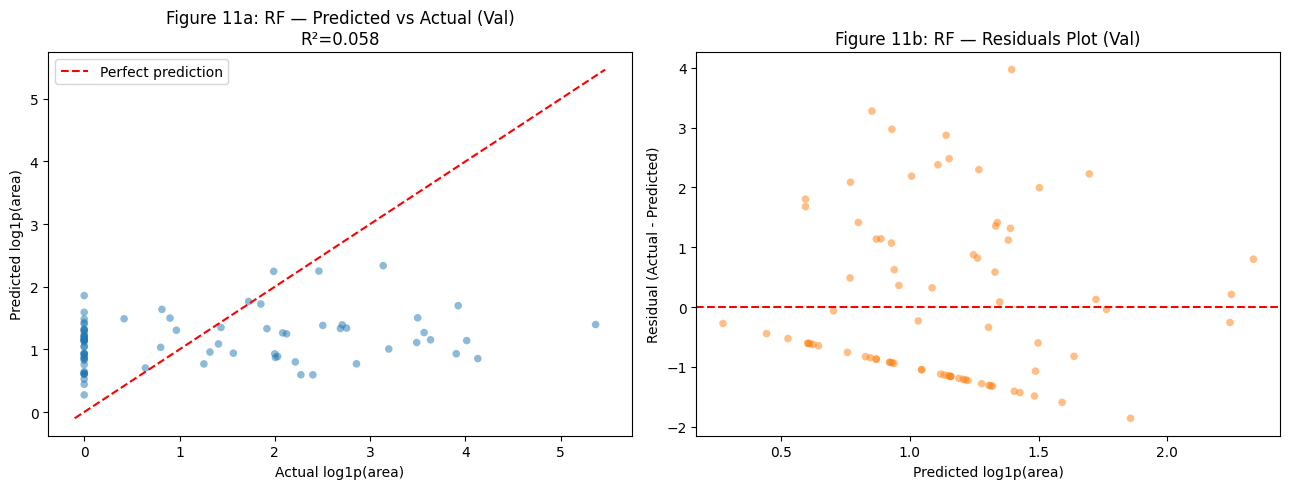

In [7]:
# Plot: Predicted vs Actual for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual (validation)
axes[0].scatter(y_val, rf_val_pred, alpha=0.5, color='#1f77b4', s=30, edgecolors='none')
lims = [min(y_val.min(), rf_val_pred.min()) - 0.1,
        max(y_val.max(), rf_val_pred.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log1p(area)')
axes[0].set_ylabel('Predicted log1p(area)')
axes[0].set_title(f'Figure 11a: RF — Predicted vs Actual (Val)\nR²={rf_val_metrics["R2"]:.3f}')
axes[0].legend()

# Residuals plot
residuals = y_val.values - rf_val_pred
axes[1].scatter(rf_val_pred, residuals, alpha=0.5, color='#ff7f0e', s=30, edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted log1p(area)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Figure 11b: RF — Residuals Plot (Val)')

plt.tight_layout()
plt.savefig('outputs/fig11_rf_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Model 2 — Multi-Layer Perceptron (MLP)

### Why MLP?
A feedforward neural network with multiple hidden layers. It serves as our deep learning baseline before the Transformer. MLPs can approximate complex non-linear functions and are widely used in sustainability applications.

**Strengths:** Flexible, learns non-linear patterns, good baseline for deep learning  
**Weaknesses:** Sensitive to hyperparameters, slower to train than Random Forest, less interpretable

In [8]:
print("=" * 55)
print("MODEL 2: Multi-Layer Perceptron (MLP)")
print("=" * 55)

class MLPRegressor(nn.Module):
    """
    Feedforward Neural Network for regression.
    Architecture: Input → [Linear → BatchNorm → ReLU → Dropout] × 3 → Output
    
    BatchNorm stabilises training by normalising layer inputs.
    Dropout (p=0.3) randomly zeros 30% of neurons to prevent overfitting.
    
    Args:
        input_dim (int): Number of input features
        hidden_dims (list): List of hidden layer sizes
        dropout (float): Dropout probability
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super(MLPRegressor, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = h_dim
        
        # Final output layer — single neuron for regression
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """Forward pass through the network."""
        return self.network(x).squeeze(-1)


def make_tensors(*arrays):
    """
    Convert numpy arrays or DataFrames to PyTorch float tensors.
    
    Args:
        *arrays: Any number of arrays/DataFrames
    Returns:
        tuple of torch.FloatTensors
    """
    return tuple(
        torch.FloatTensor(a.values if hasattr(a, 'values') else a)
        for a in arrays
    )


# Convert data to PyTorch tensors
X_train_t, y_train_t = make_tensors(X_train, y_train)
X_val_t,   y_val_t   = make_tensors(X_val,   y_val)
X_test_t,  y_test_t  = make_tensors(X_test,  y_test)

# Wrap in DataLoaders for mini-batch training
# batch_size=32 is a good default for small datasets
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Tensors created. Training batches: {len(train_loader)}")

MODEL 2: Multi-Layer Perceptron (MLP)
Tensors created. Training batches: 12


In [9]:
def train_model(model, train_loader, val_loader, n_epochs=150, lr=1e-3,
                patience=20, model_name='model'):
    """
    Train a PyTorch model with early stopping.
    
    Early stopping monitors validation loss and stops training when it stops
    improving — this prevents overfitting on small datasets.
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        n_epochs (int): Maximum training epochs
        lr (float): Learning rate for Adam optimiser
        patience (int): Epochs to wait before early stopping
        model_name (str): Name for saving the best model
    Returns:
        tuple: (trained model, train loss history, val loss history, total time)
    """
    model = model.to(device)
    
    # Adam optimiser — adapts learning rate per parameter; well-suited for NNs
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # ReduceLROnPlateau halves the learning rate if val loss stalls for 10 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, verbose=False)
    
    # MSE loss — standard for regression
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    start = time.time()
    
    for epoch in range(n_epochs):
        # --- Training phase ---
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # --- Validation phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        # Early stopping: save best model state
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
            break
        
        # Print progress every 30 epochs
        if (epoch + 1) % 30 == 0:
            print(f"  Epoch {epoch+1:>3}: Train Loss={train_loss:.4f}  Val Loss={val_loss:.4f}")
    
    total_time = time.time() - start
    
    # Restore best model weights
    if best_state:
        model.load_state_dict(best_state)
    
    # Save best model weights
    torch.save(model.state_dict(), f'outputs/models/{model_name}.pt')
    print(f"  Training complete in {total_time:.1f}s — model saved.")
    
    return model, train_losses, val_losses, total_time


def get_predictions(model, X_tensor):
    """
    Get predictions from a PyTorch model on CPU-friendly batches.
    
    Args:
        model: Trained PyTorch model
        X_tensor: Input tensor
    Returns:
        numpy array of predictions
    """
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy()
    return preds

print("Training utilities defined.")

Training utilities defined.


In [10]:
# Instantiate and train the MLP
mlp_model = MLPRegressor(
    input_dim=n_features,
    hidden_dims=[128, 64, 32],  # 3 hidden layers, progressively smaller
    dropout=0.3
)

print(f"MLP Architecture:")
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

print("\nTraining MLP...")
mlp_model, mlp_train_loss, mlp_val_loss, mlp_time = train_model(
    mlp_model, train_loader, val_loader,
    n_epochs=200, lr=1e-3, patience=25,
    model_name='mlp'
)

MLP Architecture:
MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 13,249

Training MLP...
  Epoch  30: Train Loss=1.9293  Val Loss=2.6993
  Early stopping at epoch 48 (best val loss: 2.6397)
  Training complete in 5.3s — model saved.


In [11]:
# Evaluate MLP
mlp_train_pred = get_predictions(mlp_model, X_train_t)
mlp_val_pred   = get_predictions(mlp_model, X_val_t)
mlp_test_pred  = get_predictions(mlp_model, X_test_t)

print("MLP Performance:")
mlp_train_metrics = evaluate_model(y_train, mlp_train_pred, 'MLP — Train')
mlp_val_metrics   = evaluate_model(y_val,   mlp_val_pred,   'MLP — Validation')
mlp_test_metrics  = evaluate_model(y_test,  mlp_test_pred,  'MLP — Test')

# Model size in MB
mlp_size_mb = sum(p.numel() * p.element_size() for p in mlp_model.parameters()) / 1e6
print(f"\nModel size: {mlp_size_mb:.4f} MB")

all_results['MLP'] = {
    'train': mlp_train_metrics,
    'val':   mlp_val_metrics,
    'test':  mlp_test_metrics,
    'train_time_s': mlp_time,
    'size_mb': mlp_size_mb,
    'val_preds':  mlp_val_pred.tolist(),
    'test_preds': mlp_test_pred.tolist(),
    'train_losses': mlp_train_loss,
    'val_losses':   mlp_val_loss
}

MLP Performance:
  MLP — Train                    MAE=0.9818  RMSE=1.2476  R²=0.2040
  MLP — Validation               MAE=1.2555  RMSE=1.5327  R²=-0.1695
  MLP — Test                     MAE=1.0238  RMSE=1.3521  R²=0.0134

Model size: 0.0530 MB


---
## 4. Model 3 — Tabular Transformer

### Why a Transformer?
Transformers use **self-attention** to learn which features matter most for each prediction — dynamically weighting relationships between input features. Originally designed for text (Vaswani et al., 2017), they have been successfully applied to tabular data and time series.

This is directly inspired by **Nascimento et al. (2023)** — *"A transformer-based deep neural network with wavelet transform for forecasting wind speed and wind energy"* — from the module reading list, applied here to environmental fire data.

The key module lecture topics covered: Week 3 (time series), Week 4 (deep learning for sequences), Week 6 (explainable AI).

**Strengths:** Captures feature interactions via attention; state-of-the-art; produces interpretable attention maps  
**Weaknesses:** More parameters, slower to train, needs careful tuning

In [12]:
print("=" * 55)
print("MODEL 3: Tabular Transformer")
print("=" * 55)

class TabularTransformer(nn.Module):
    """
    Transformer-based model for tabular regression.
    
    Architecture:
      1. Feature embedding: each scalar feature is projected to d_model dimensions
         This allows the Transformer encoder to treat each feature as a 'token'
      2. Positional encoding: adds learnable positional information per feature
      3. Transformer encoder: applies multi-head self-attention across features
         Self-attention allows the model to learn which features interact
      4. Pooling: average the feature representations across the sequence
      5. MLP head: final regression prediction from the pooled representation
    
    Inspired by: Nascimento et al. (2023), Energy, 278, 127678.
    
    Args:
        input_dim (int): Number of input features
        d_model (int): Embedding dimension (each feature maps to d_model values)
        nhead (int): Number of attention heads (d_model must be divisible by nhead)
        num_encoder_layers (int): Number of stacked transformer encoder blocks
        dim_feedforward (int): Size of the feedforward sublayer inside encoder
        dropout (float): Dropout rate
    """
    def __init__(self, input_dim, d_model=64, nhead=4,
                 num_encoder_layers=2, dim_feedforward=128, dropout=0.2):
        super(TabularTransformer, self).__init__()
        
        self.input_dim = input_dim
        self.d_model   = d_model
        
        # Step 1: Project each scalar feature to d_model dimensions
        # Each feature becomes a 'token' of size d_model
        self.feature_embedding = nn.Linear(1, d_model)
        
        # Step 2: Learnable positional encoding — tells the model which feature is which
        self.positional_encoding = nn.Parameter(torch.randn(input_dim, d_model))
        
        # Step 3: Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True   # input shape: (batch, seq_len, d_model)
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )
        
        # Step 4 & 5: MLP regression head
        self.regression_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input tensor of shape (batch_size, input_dim)
        Returns:
            Predictions of shape (batch_size,)
        """
        batch_size = x.size(0)
        
        # Reshape: (batch, features) → (batch, features, 1)
        # Each feature is treated as a separate token
        x = x.unsqueeze(-1)
        
        # Embed each feature: (batch, features, 1) → (batch, features, d_model)
        x = self.feature_embedding(x)
        
        # Add positional encoding (broadcasted across batch)
        x = x + self.positional_encoding.unsqueeze(0)
        
        # Transformer encoder: learns feature interactions via self-attention
        x = self.transformer_encoder(x)  # (batch, features, d_model)
        
        # Mean pooling across the feature dimension
        x = x.mean(dim=1)  # (batch, d_model)
        
        # Regression head
        out = self.regression_head(x).squeeze(-1)  # (batch,)
        return out


# Instantiate the Transformer
transformer_model = TabularTransformer(
    input_dim=n_features,
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=128,
    dropout=0.2
)

print("Transformer Architecture:")
print(transformer_model)
total_params_t = sum(p.numel() for p in transformer_model.parameters())
print(f"\nTotal trainable parameters: {total_params_t:,}")

MODEL 3: Tabular Transformer
Transformer Architecture:
TabularTransformer(
  (feature_embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (regression_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=

In [13]:
# Train the Transformer
print("Training Tabular Transformer...")
transformer_model, tf_train_loss, tf_val_loss, tf_time = train_model(
    transformer_model, train_loader, val_loader,
    n_epochs=200, lr=5e-4, patience=30,
    model_name='transformer'
)
# Note: lower learning rate (5e-4) for Transformer — it benefits from more stable updates

Training Tabular Transformer...
  Epoch  30: Train Loss=1.9678  Val Loss=2.3982
  Early stopping at epoch 32 (best val loss: 2.2618)
  Training complete in 6.1s — model saved.


In [14]:
# Evaluate Transformer
tf_train_pred = get_predictions(transformer_model, X_train_t)
tf_val_pred   = get_predictions(transformer_model, X_val_t)
tf_test_pred  = get_predictions(transformer_model, X_test_t)

print("Transformer Performance:")
tf_train_metrics = evaluate_model(y_train, tf_train_pred, 'Transformer — Train')
tf_val_metrics   = evaluate_model(y_val,   tf_val_pred,   'Transformer — Validation')
tf_test_metrics  = evaluate_model(y_test,  tf_test_pred,  'Transformer — Test')

tf_size_mb = sum(p.numel() * p.element_size() for p in transformer_model.parameters()) / 1e6
print(f"\nModel size: {tf_size_mb:.4f} MB")

all_results['Transformer'] = {
    'train': tf_train_metrics,
    'val':   tf_val_metrics,
    'test':  tf_test_metrics,
    'train_time_s': tf_time,
    'size_mb': tf_size_mb,
    'val_preds':  tf_val_pred.tolist(),
    'test_preds': tf_test_pred.tolist(),
    'train_losses': tf_train_loss,
    'val_losses':   tf_val_loss
}

Transformer Performance:
  Transformer — Train            MAE=1.1853  RMSE=1.3997  R²=-0.0019
  Transformer — Validation       MAE=1.2481  RMSE=1.4185  R²=-0.0018
  Transformer — Test             MAE=1.1131  RMSE=1.3806  R²=-0.0285

Model size: 0.2813 MB


## 5. Training Curves

Training and validation loss curves reveal how each model learned over epochs and whether overfitting occurred.

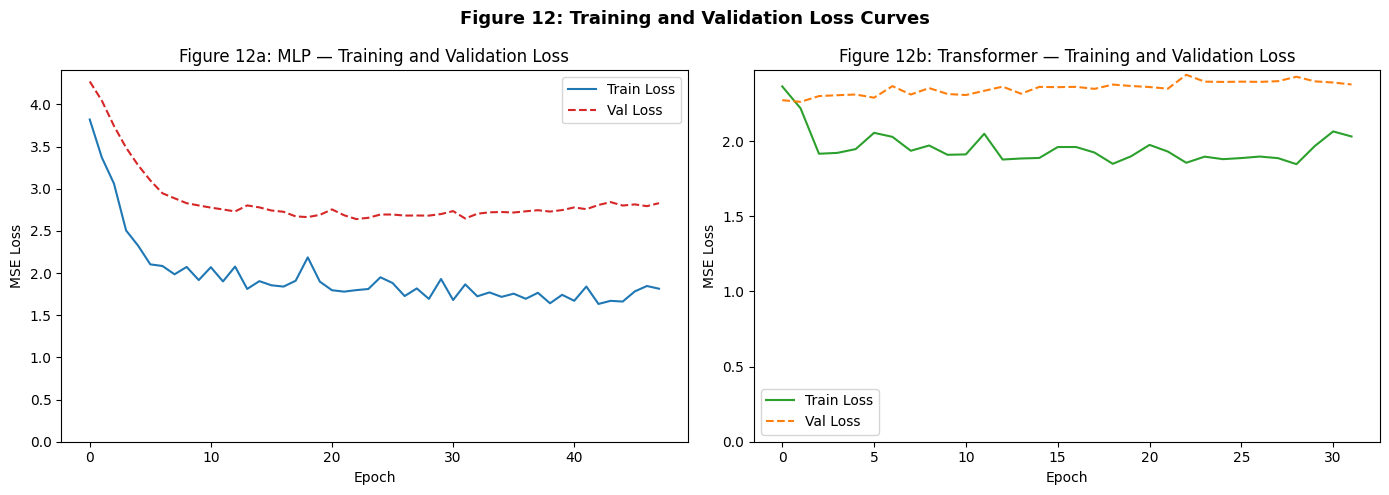

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP training curves
axes[0].plot(mlp_train_loss, label='Train Loss', color='#1f77b4', linewidth=1.5)
axes[0].plot(mlp_val_loss,   label='Val Loss',   color='#d62728', linewidth=1.5, linestyle='--')
axes[0].set_title('Figure 12a: MLP — Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# Transformer training curves
axes[1].plot(tf_train_loss, label='Train Loss', color='#2ca02c', linewidth=1.5)
axes[1].plot(tf_val_loss,   label='Val Loss',   color='#ff7f0e', linewidth=1.5, linestyle='--')
axes[1].set_title('Figure 12b: Transformer — Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].set_ylim(bottom=0)

plt.suptitle('Figure 12: Training and Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig12_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison Summary

In [16]:
# Build a comparison table — Test set performance
comparison_rows = []
for model_name, results in all_results.items():
    comparison_rows.append({
        'Model':          model_name,
        'Test MAE':       round(results['test']['MAE'], 4),
        'Test RMSE':      round(results['test']['RMSE'], 4),
        'Test R²':        round(results['test']['R2'], 4),
        'Val R²':         round(results['val']['R2'], 4),
        'Train Time (s)': round(results['train_time_s'], 1),
        'Size (MB)':      round(results['size_mb'], 4)
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 75)
print("MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 75)
print(comparison_df.to_string(index=False))

# Identify best model by RMSE
best_model = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
print(f"\n→ Best model by Test RMSE: {best_model}")

# Save comparison table
comparison_df.to_csv('outputs/model_comparison.csv', index=False)
print("Comparison table saved to outputs/model_comparison.csv")

MODEL COMPARISON — TEST SET PERFORMANCE
        Model  Test MAE  Test RMSE  Test R²  Val R²  Train Time (s)  Size (MB)
Random Forest    1.1056     1.3822  -0.0310  0.0585            27.3     1.1626
          MLP    1.0238     1.3521   0.0134 -0.1695             5.3     0.0530
  Transformer    1.1131     1.3806  -0.0285 -0.0018             6.1     0.2813

→ Best model by Test RMSE: MLP
Comparison table saved to outputs/model_comparison.csv


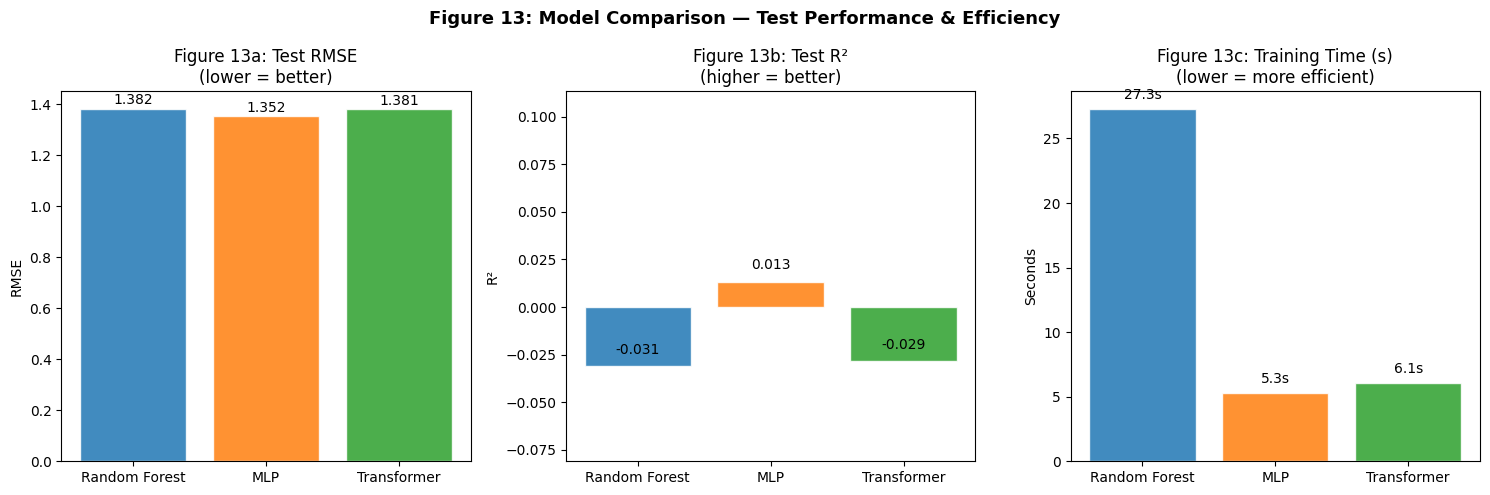

In [17]:
# Visual comparison: Test RMSE and R² per model
models      = comparison_df['Model'].tolist()
test_rmse   = comparison_df['Test RMSE'].tolist()
test_r2     = comparison_df['Test R²'].tolist()
bar_colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE — lower is better
bars = axes[0].bar(models, test_rmse, color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 13a: Test RMSE\n(lower = better)')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, test_rmse):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# R² — higher is better
bars = axes[1].bar(models, test_r2, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Figure 13b: Test R²\n(higher = better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim([min(0, min(test_r2)) - 0.05, max(test_r2) + 0.1])
for bar, val in zip(bars, test_r2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Training time — lower is better
train_times = comparison_df['Train Time (s)'].tolist()
bars = axes[2].bar(models, train_times, color=bar_colors, edgecolor='white', alpha=0.85)
axes[2].set_title('Figure 13c: Training Time (s)\n(lower = more efficient)')
axes[2].set_ylabel('Seconds')
for bar, val in zip(bars, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}s', ha='center', va='bottom', fontsize=10)

plt.suptitle('Figure 13: Model Comparison — Test Performance & Efficiency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig13_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save All Results

In [18]:
# Save all model results for Notebooks 4 and 5
# Remove non-serialisable numpy arrays before saving to JSON
results_to_save = {}
for model_name, res in all_results.items():
    results_to_save[model_name] = {
        'train': res['train'],
        'val':   res['val'],
        'test':  res['test'],
        'train_time_s': res['train_time_s'],
        'size_mb': res['size_mb'],
        'val_preds':  res['val_preds'],
        'test_preds': res['test_preds']
    }

with open('outputs/all_model_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("All results saved to outputs/all_model_results.json")
print("\nFiles in outputs/models/:")
for f in os.listdir('outputs/models'):
    size = os.path.getsize(f'outputs/models/{f}')
    print(f"  {f}  ({size/1e3:.1f} KB)")

print("\n→ Next step: Notebook 4 — Evaluation and Explainable AI")

All results saved to outputs/all_model_results.json

Files in outputs/models/:
  mlp.pt  (61.0 KB)
  random_forest.pkl  (2711.2 KB)
  transformer.pt  (293.4 KB)

→ Next step: Notebook 4 — Evaluation and Explainable AI
